In [108]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

data_path = "../data/raw/HI-Medium_Trans.csv"

In [109]:
transactions = pl.scan_csv(
    data_path,
    infer_schema_length=1000
)

transactions

In [110]:
total_rows = (
    transactions
    .select(
        pl.len().alias("rows")
    )
    .collect(engine="streaming")
)

total_rows

rows
u32
31898238


In [111]:
transactions.collect_schema()

Schema([('Timestamp', String),
        ('From Bank', Int64),
        ('Account', String),
        ('To Bank', Int64),
        ('Account_duplicated_0', String),
        ('Amount Received', Float64),
        ('Receiving Currency', String),
        ('Amount Paid', Float64),
        ('Payment Currency', String),
        ('Payment Format', String),
        ('Is Laundering', Int64)])

In [112]:
df = transactions.rename({
    "Timestamp": "timestamp",
    "From Bank": "from_bank",
    "Account": "from_account",
    "To Bank": "to_bank",
    "Account_duplicated_0": "to_account",
    "Amount Received": "amount_received",
    "Receiving Currency": "receiving_currency",
    "Amount Paid": "amount_paid",
    "Payment Currency": "payment_currency",
    "Payment Format": "payment_format",
    "Is Laundering": "is_laundering"
})

df = df.with_columns(
    pl.col("timestamp")
    .str.strptime(
        pl.Datetime,
        "%Y/%m/%d %H:%M",
        strict=False
    )
    .alias("timestamp")
)

In [113]:
df.collect_schema()

Schema([('timestamp', Datetime(time_unit='us', time_zone=None)),
        ('from_bank', Int64),
        ('from_account', String),
        ('to_bank', Int64),
        ('to_account', String),
        ('amount_received', Float64),
        ('receiving_currency', String),
        ('amount_paid', Float64),
        ('payment_currency', String),
        ('payment_format', String),
        ('is_laundering', Int64)])

In [114]:
df.head(10).collect()

timestamp,from_bank,from_account,to_bank,to_account,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering
datetime[μs],i64,str,i64,str,f64,str,f64,str,str,i64
2022-09-01 00:17:00,20,"""800104D70""",20,"""800104D70""",6794.63,"""US Dollar""",6794.63,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:02:00,3196,"""800107150""",3196,"""800107150""",7739.29,"""US Dollar""",7739.29,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:17:00,1208,"""80010E430""",1208,"""80010E430""",1880.23,"""US Dollar""",1880.23,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:03:00,1208,"""80010E650""",20,"""80010E6F0""",7.3966883e7,"""US Dollar""",7.3966883e7,"""US Dollar""","""Cheque""",0
2022-09-01 00:02:00,1208,"""80010E650""",20,"""80010EA30""",4.5868454e7,"""US Dollar""",4.5868454e7,"""US Dollar""","""Cheque""",0
2022-09-01 00:27:00,3203,"""80010EA80""",3203,"""80010EA80""",13284.41,"""US Dollar""",13284.41,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:25:00,20,"""800104D20""",20,"""800104D20""",9.72,"""US Dollar""",9.72,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:09:00,1208,"""80010E430""",1208,"""80010E430""",7.66,"""US Dollar""",7.66,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:09:00,11,"""80010E600""",11,"""80010E600""",16.33,"""US Dollar""",16.33,"""US Dollar""","""Reinvestment""",0


## Check Date Range 

### This analysis identifies the earliest and latest transaction timestamps in the dataset. It helps determine the overall time period covered by the transaction data and supports later temporal and sequential analysis.

In [115]:
date_range = df.select(
    pl.col("timestamp").min().alias("min_date"),
    pl.col("timestamp").max().alias("max_date")
)

date_range.collect()

min_date,max_date
datetime[μs],datetime[μs]
2022-09-01 00:00:00,2022-09-28 15:58:00


The dataset covers transactions from 1 September 2022 at 00:00 to 28 September 2022 at 15:58. Therefore, the dataset represents approximately 28 days of transaction activity.

## Check Failed Timestamps

### This check verifies whether any timestamp values failed during conversion from string format to datetime format. Valid timestamps are important because the project relies on chronological ordering of transactions.

In [116]:
timestamp_check = (
    df.select(
        pl.col("timestamp")
        .null_count()
        .alias("failed_timestamp_count")
    )
    .collect(engine="streaming")
)

timestamp_check

failed_timestamp_count
u32
0


The failed timestamp count is 0, indicating that all timestamp values were successfully converted to datetime format. Therefore, no timestamp-related data cleaning is required.

## Missing values

### This analysis checks each feature for null or missing values. Identifying missing data is important because incomplete records may require removal, imputation, or other preprocessing before model training.

In [117]:
null_counts = (
    df
    .select(pl.all().null_count())
    .collect(engine="streaming")
)

null_counts

timestamp,from_bank,from_account,to_bank,to_account,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0


No missing values were found in any of the dataset columns. Therefore, no missing-value imputation is required for the current dataset.

## Check target values 

### This analysis examines the distribution of the target variable, `is_laundering`. It determines the number and percentage of legitimate and laundering transactions and helps identify class imbalance.

In [118]:
target_values = (
    df.group_by("is_laundering")
      .agg(
          pl.len().alias("count")
      )
      .sort("is_laundering")
      .collect(engine="streaming")
)

target_values

is_laundering,count
i64,u32
0,31863008
1,35230


In [119]:
target_values = target_values.with_columns(
    (
        pl.col("count") /
        pl.col("count").sum() * 100
    ).alias("percentage")
)

target_values

is_laundering,count,percentage
i64,u32,f64
0,31863008,99.889555
1,35230,0.110445


The dataset contains 31,863,008 legitimate transactions and 35,230 laundering transactions. Legitimate transactions represent approximately 99.89% of the data, while laundering transactions represent only 0.11%. This confirms that the AML classification problem is extremely imbalanced.

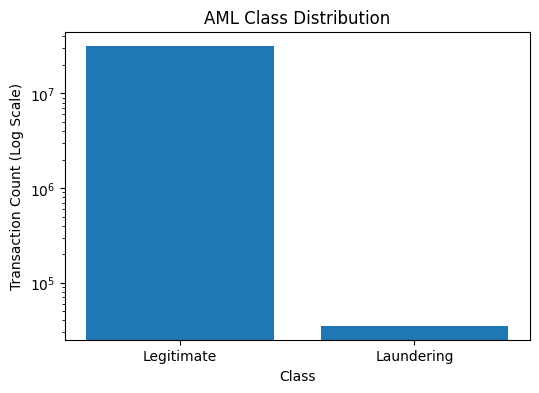

In [120]:
plt.figure(figsize=(6, 4))

plt.bar(
    target_values["is_laundering"],
    target_values["count"]
)

plt.yscale("log")

plt.xticks(
    [0, 1],
    ["Legitimate", "Laundering"]
)

plt.xlabel("Class")
plt.ylabel("Transaction Count (Log Scale)")
plt.title("AML Class Distribution")

plt.show()

A logarithmic y-axis is used because the legitimate class is substantially larger than the laundering class. Without the log scale, the laundering class would be difficult to observe visually.

## Check amount quality

### This analysis checks the transaction amount features for negative values, zero values, and missing values. These checks help identify potentially invalid or structurally problematic financial records.

In [121]:
df.head(10).collect()

timestamp,from_bank,from_account,to_bank,to_account,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering
datetime[μs],i64,str,i64,str,f64,str,f64,str,str,i64
2022-09-01 00:17:00,20,"""800104D70""",20,"""800104D70""",6794.63,"""US Dollar""",6794.63,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:02:00,3196,"""800107150""",3196,"""800107150""",7739.29,"""US Dollar""",7739.29,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:17:00,1208,"""80010E430""",1208,"""80010E430""",1880.23,"""US Dollar""",1880.23,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:03:00,1208,"""80010E650""",20,"""80010E6F0""",7.3966883e7,"""US Dollar""",7.3966883e7,"""US Dollar""","""Cheque""",0
2022-09-01 00:02:00,1208,"""80010E650""",20,"""80010EA30""",4.5868454e7,"""US Dollar""",4.5868454e7,"""US Dollar""","""Cheque""",0
2022-09-01 00:27:00,3203,"""80010EA80""",3203,"""80010EA80""",13284.41,"""US Dollar""",13284.41,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:25:00,20,"""800104D20""",20,"""800104D20""",9.72,"""US Dollar""",9.72,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:09:00,1208,"""80010E430""",1208,"""80010E430""",7.66,"""US Dollar""",7.66,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:09:00,11,"""80010E600""",11,"""80010E600""",16.33,"""US Dollar""",16.33,"""US Dollar""","""Reinvestment""",0


In [122]:
amount_quality = df.select(
    [

        ## amount paid
        (pl.col("amount_paid")< 0).sum().alias("negative_amount_paid"),

        (pl.col("amount_paid")==0).sum().alias("zero_amount_paid"),

        (pl.col("amount_paid").null_count()).sum().alias("null_amount_paid"),

        ## amount received
        (pl.col("amount_received")< 0).sum().alias("negative_amount_received"),

        (pl.col("amount_received")==0).sum().alias("zero_amount_received"),

        (pl.col("amount_received").null_count()).sum().alias("null_amount_received"),
        ]
).collect(engine="streaming")


amount_quality

negative_amount_paid,zero_amount_paid,null_amount_paid,negative_amount_received,zero_amount_received,null_amount_received
u32,u32,u32,u32,u32,u32
0,0,0,0,0,0


No negative, zero, or null values were found in either `amount_paid` or `amount_received`. Therefore, the transaction amount columns do not contain obvious structural data-quality problems based on these checks.

## Amount Statistics

### This analysis examines the statistical distribution of transaction amounts using the minimum, maximum, mean, standard deviation, median, and selected quantiles. It helps identify skewness, extreme values, and the general scale of transaction amounts.

In [123]:
amount_stats = df.select(
    [
        ## amount paid
        (pl.col("amount_paid").min().alias("min_amount_paid")),
        (pl.col("amount_paid").max().alias("max_amount_paid")),
        (pl.col("amount_paid").mean().alias("mean_amount_paid")),
        (pl.col("amount_paid").std().alias("std_amount_paid")),
        (pl.col("amount_paid").median().alias("median_amount_paid")),
        (pl.col("amount_paid").quantile(0.25).alias("q1_amount_paid")),
        (pl.col("amount_paid").quantile(0.75).alias("q3_amount_paid")),
        (pl.col("amount_paid").quantile(0.95).alias("q95_amount_paid")),
        (pl.col("amount_paid").quantile(0.99).alias("q99_amount_paid")),

        ## amount received
        (pl.col("amount_received").min().alias("min_amount_received")),
        (pl.col("amount_received").max().alias("max_amount_received")),
        (pl.col("amount_received").mean().alias("mean_amount_received")),
        (pl.col("amount_received").std().alias("std_amount_received")),
        (pl.col("amount_received").median().alias("median_amount_received")),
        (pl.col("amount_received").quantile(0.25).alias("q1_amount_received")),
        (pl.col("amount_received").quantile(0.75).alias("q3_amount_received")),
        (pl.col("amount_received").quantile(0.95).alias("q95_amount_received")),
        (pl.col("amount_received").quantile(0.99).alias("q99_amount_received"))
    ]
).collect(engine="streaming")


In [124]:
print("amount_paid")
print("min_amount_paid:", amount_stats["min_amount_paid"][0])
print("max_amount_paid:", amount_stats["max_amount_paid"][0])
print("mean_amount_paid:", amount_stats["mean_amount_paid"][0])
print("std_amount_paid:", amount_stats["std_amount_paid"][0])
print("median_amount_paid:", amount_stats["median_amount_paid"][0])
print("q1_amount_paid:", amount_stats["q1_amount_paid"][0])
print("q3_amount_paid:", amount_stats["q3_amount_paid"][0])
print("q95_amount_paid:", amount_stats["q95_amount_paid"][0])
print("q99_amount_paid:", amount_stats["q99_amount_paid"][0])

print("amount_received")
print("min_amount_received:", amount_stats["min_amount_received"][0])
print("max_amount_received:", amount_stats["max_amount_received"][0])
print("mean_amount_received:", amount_stats["mean_amount_received"][0])
print("std_amount_received:", amount_stats["std_amount_received"][0])
print("median_amount_received:", amount_stats["median_amount_received"][0])
print("q1_amount_received:", amount_stats["q1_amount_received"][0])
print("q3_amount_received:", amount_stats["q3_amount_received"][0])
print("q95_amount_received:", amount_stats["q95_amount_received"][0])
print("q99_amount_received:", amount_stats["q99_amount_received"][0])

amount_paid
min_amount_paid: 1e-06
max_amount_paid: 8158609321727.61
mean_amount_paid: 4417550.924693704
std_amount_paid: 1848313490.2596703
median_amount_paid: 1471.54
q1_amount_paid: 209.23
q3_amount_paid: 11757.81
q95_amount_paid: 533159.46
q99_amount_paid: 10650398.38
amount_received
min_amount_received: 1e-06
max_amount_received: 8158609321727.61
mean_amount_received: 6431116.010015257
std_amount_received: 2592744242.711327
median_amount_received: 1469.25
q1_amount_received: 207.87
q3_amount_received: 11835.3
q95_amount_received: 555119.94
q99_amount_received: 11503705.86


Both amount features are highly right-skewed. For `amount_paid`, the median is approximately 1,471.54 while the mean is approximately 4.42 million, and the maximum exceeds 8.15 trillion. A similar pattern is observed for `amount_received`. The large difference between the median, mean, upper quantiles, and maximum values indicates the presence of extreme high-value transactions.

In [125]:
SAMPLE_SIZE = 100_000
sampling_step = max(total_rows["rows"][0] // SAMPLE_SIZE, 1)

sample_df = (
    df
    .select([
        "amount_paid",
        "amount_received"
    ])
    .filter(
        (pl.col("amount_paid").is_not_null()) &
        (pl.col("amount_received").is_not_null())
    )
    .gather_every(sampling_step)
    .limit(SAMPLE_SIZE)
    .collect(engine="streaming")
)

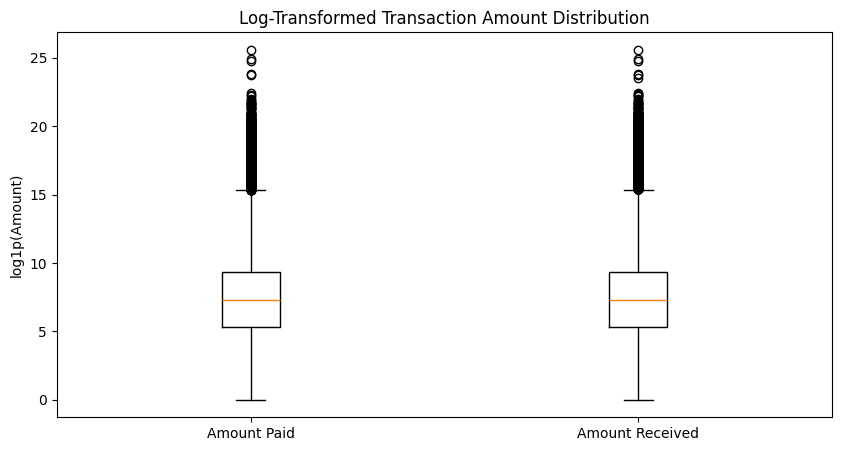

In [126]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    [
        np.log1p(sample_df["amount_paid"].to_numpy()),
        np.log1p(sample_df["amount_received"].to_numpy())
    ],
    tick_labels=[
        "Amount Paid",
        "Amount Received"
    ],
    showfliers=True
)

plt.ylabel("log1p(Amount)")
plt.title("Log-Transformed Transaction Amount Distribution")

plt.show()

The log-transformed boxplot compresses the very large transaction values and makes the underlying amount distribution easier to visualize. Extreme transactions are retained because unusually large transactions may contain useful AML information rather than simply representing invalid data.

## Payment Formats

### This analysis examines how transactions are distributed across different payment formats. Understanding the categorical distribution helps identify dominant transaction channels and informs the encoding strategy used during preprocessing.

In [127]:
payment_format = (
    df.group_by("payment_format")
    .agg(
        pl.len().alias("count")
    )
    .sort("count", descending=True)
    .collect(engine="streaming")
)

payment_format 

payment_format,count
str,u32
"""Cheque""",12280058
"""Credit Card""",8777816
"""ACH""",3868410
"""Cash""",3217531
"""Reinvestment""",1945611
"""Wire""",1119774
"""Bitcoin""",689038


Text(0.5, 1.0, 'Transaction Count by Payment Format')

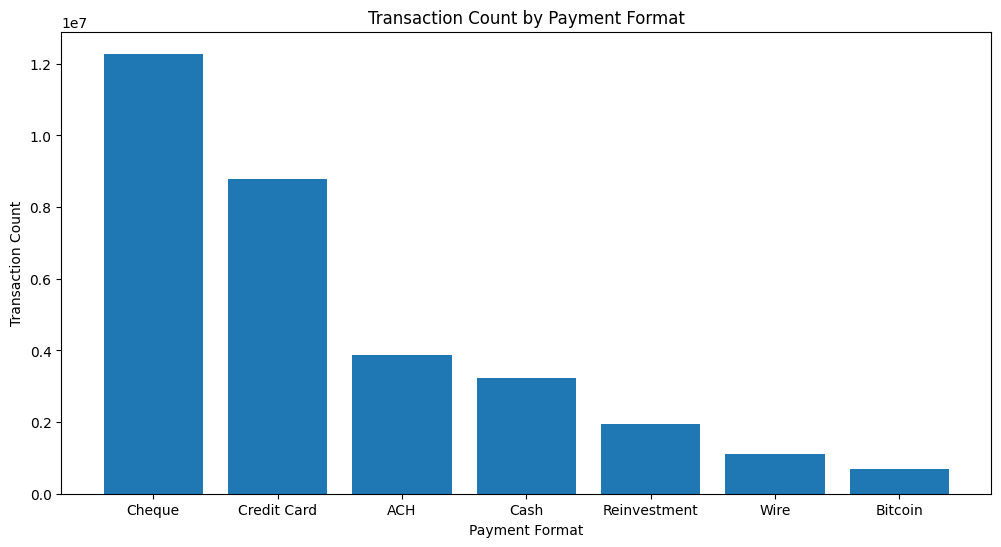

In [128]:
plt.figure(figsize=(12, 6))
plt.bar(
    payment_format["payment_format"],
    payment_format["count"]
)

plt.xlabel("Payment Format")
plt.ylabel("Transaction Count")
plt.title("Transaction Count by Payment Format")

Seven payment formats are present in the dataset. Cheque transactions are the most common with approximately 12.28 million records, followed by Credit Card transactions with approximately 8.78 million. ACH, Cash, Reinvestment, Wire, and Bitcoin transactions occur less frequently.

## Payment currencies

### This analysis examines the currencies used to send payments. It identifies the number of supported currencies and their transaction frequencies, which is useful for understanding the categorical structure of the dataset.

In [129]:
payment_currency = (
    df.group_by("payment_currency")
    .agg(
        pl.len().alias("count")
    )
    .sort("count", descending=True)
    .collect(engine="streaming")
)

payment_currency

payment_currency,count
str,u32
"""US Dollar""",11688249
"""Euro""",7315958
"""Yuan""",2330638
"""Shekel""",1408707
"""Canadian Dollar""",1078358
…,…
"""Mexican Peso""",841257
"""Rupee""",738718
"""Bitcoin""",688914


The dataset contains 15 payment currencies. US Dollar is the most frequently used payment currency with approximately 11.69 million transactions, followed by Euro with approximately 7.32 million transactions. The remaining currencies occur at lower frequencies.

## Receiving currencies

### This analysis examines the currencies in which transaction values were received. Comparing payment and receiving currencies is useful for identifying transactions involving currency conversion.

In [130]:
receiving_currencies = (
    df.group_by("receiving_currency")
    .agg(
        pl.len().alias("count")
    )
    .sort("count", descending=True)
    .collect(engine="streaming")
)

receiving_currencies

receiving_currency,count
str,u32
"""US Dollar""",11594241
"""Euro""",7329170
"""Yuan""",2295849
"""Shekel""",1428622
"""Canadian Dollar""",1089398
…,…
"""Mexican Peso""",852272
"""Rupee""",741594
"""Bitcoin""",698372


The dataset contains 15 receiving currencies. US Dollar and Euro are the most frequently observed receiving currencies, with approximately 11.59 million and 7.33 million transactions respectively. Their overall distribution is similar to the payment-currency distribution.

## Cross Currency Transaction

### This analysis identifies transactions where the payment currency differs from the receiving currency. Cross-currency activity may provide useful behavioral information for later feature engineering and AML modeling.

In [131]:
df.collect_schema()

Schema([('timestamp', Datetime(time_unit='us', time_zone=None)),
        ('from_bank', Int64),
        ('from_account', String),
        ('to_bank', Int64),
        ('to_account', String),
        ('amount_received', Float64),
        ('receiving_currency', String),
        ('amount_paid', Float64),
        ('payment_currency', String),
        ('payment_format', String),
        ('is_laundering', Int64)])

In [132]:
df = df.with_columns(
    (
        pl.col("payment_currency") != pl.col("receiving_currency")
    ).alias("is_cross_currency")
)

In [133]:
df.collect_schema()

Schema([('timestamp', Datetime(time_unit='us', time_zone=None)),
        ('from_bank', Int64),
        ('from_account', String),
        ('to_bank', Int64),
        ('to_account', String),
        ('amount_received', Float64),
        ('receiving_currency', String),
        ('amount_paid', Float64),
        ('payment_currency', String),
        ('payment_format', String),
        ('is_laundering', Int64),
        ('is_cross_currency', Boolean)])

In [134]:
cross_currency_transaction = df.select(
    [
    pl.len().alias("total_transactions"),
    pl.col("is_cross_currency").sum().alias("cross_currency_transactions"),
    (pl.col("is_cross_currency").mean()*100).alias("cross_currency_rate(%)"),
    ]
).collect(engine="streaming")

cross_currency_transaction

total_transactions,cross_currency_transactions,cross_currency_rate(%)
u32,u32,f64
31898238,485144,1.520912


Out of 31,898,238 transactions, 485,144 are cross-currency transactions. This represents approximately 1.52% of all transactions, indicating that the large majority of transactions use the same payment and receiving currency.

## Cross Bank Transaction

### This analysis identifies transactions where the sender bank and receiver bank are different. It helps describe how frequently transactions occur between different banks compared with transactions occurring within the same bank.

In [135]:
df = df.with_columns(
    (
        pl.col("from_bank") != pl.col("to_bank")
    ).alias("is_cross_bank")
)

In [136]:
df.collect_schema()

Schema([('timestamp', Datetime(time_unit='us', time_zone=None)),
        ('from_bank', Int64),
        ('from_account', String),
        ('to_bank', Int64),
        ('to_account', String),
        ('amount_received', Float64),
        ('receiving_currency', String),
        ('amount_paid', Float64),
        ('payment_currency', String),
        ('payment_format', String),
        ('is_laundering', Int64),
        ('is_cross_currency', Boolean),
        ('is_cross_bank', Boolean)])

In [137]:
cross_bank_transaction = df.select(
    [
    pl.len().alias("total_transactions"),
    pl.col("is_cross_bank").sum().alias("cross_bank_transactions"),
    (pl.col("is_cross_bank").mean()*100).alias("cross_bank_rate(%)"),
    ]  
).collect(engine="streaming")

cross_bank_transaction

total_transactions,cross_bank_transactions,cross_bank_rate(%)
u32,u32,f64
31898238,29092624,91.204486


Approximately 29.09 million transactions are cross-bank transactions, representing about 91.20% of the entire dataset. This indicates that most transactions in the dataset occur between accounts associated with different banks.

## Same Account Transfer

### This analysis identifies transactions where both the sender and receiver belong to the same bank and have the same account identifier. It helps quantify transactions that effectively return funds to the same account identity.

In [138]:
df = df.with_columns(
    (
        (pl.col("from_bank") == pl.col("to_bank"))
        &
        (pl.col("from_account") == pl.col("to_account"))
    ).alias("is_same_account_transfer")
)

In [139]:
df.collect_schema()

Schema([('timestamp', Datetime(time_unit='us', time_zone=None)),
        ('from_bank', Int64),
        ('from_account', String),
        ('to_bank', Int64),
        ('to_account', String),
        ('amount_received', Float64),
        ('receiving_currency', String),
        ('amount_paid', Float64),
        ('payment_currency', String),
        ('payment_format', String),
        ('is_laundering', Int64),
        ('is_cross_currency', Boolean),
        ('is_cross_bank', Boolean),
        ('is_same_account_transfer', Boolean)])

In [140]:
same_account_transfer = df.select(
    [
    pl.len().alias("total_transactions"),
    pl.col("is_same_account_transfer").sum().alias("same_account_transfer_transactions"),
    (pl.col("is_same_account_transfer").mean()*100).alias("same_account_transfer_rate(%)"),
    ]
).collect(engine="streaming")

same_account_transfer

total_transactions,same_account_transfer_transactions,same_account_transfer_rate(%)
u32,u32,f64
31898238,2561860,8.031353


The dataset contains 2,561,860 same-account transfers, representing approximately 8.03% of all transactions. Therefore, a meaningful portion of the dataset contains transactions where the sender and receiver account identities are identical.

## Unique Accounts

### This analysis creates unique sender and receiver identifiers by combining the bank identifier with the account identifier. It then measures the number of distinct sender accounts, receiver accounts, and banks represented in the dataset.

In [141]:
df = df.with_columns(
    [
        pl.concat_str(
            [
                pl.col("from_bank"),
                pl.col("from_account")
            ], separator="-"
        ).alias("sender_id"),
        pl.concat_str(
            [
                pl.col("to_bank"),
                pl.col("to_account")
            ], separator="-"
        ).alias("receiver_id")
    ]
)

In [142]:
df.collect_schema()

Schema([('timestamp', Datetime(time_unit='us', time_zone=None)),
        ('from_bank', Int64),
        ('from_account', String),
        ('to_bank', Int64),
        ('to_account', String),
        ('amount_received', Float64),
        ('receiving_currency', String),
        ('amount_paid', Float64),
        ('payment_currency', String),
        ('payment_format', String),
        ('is_laundering', Int64),
        ('is_cross_currency', Boolean),
        ('is_cross_bank', Boolean),
        ('is_same_account_transfer', Boolean),
        ('sender_id', String),
        ('receiver_id', String)])

In [143]:
account_count = df.select([
    pl.col("sender_id").n_unique().alias("unique_senders"),
    pl.col("receiver_id").n_unique().alias("unique_receivers"),
    pl.col("from_bank").n_unique().alias("unique_sender_banks"),
    pl.col("to_bank").n_unique().alias("unique_receiver_banks")
]).collect(engine="streaming")

account_count

unique_senders,unique_receivers,unique_sender_banks,unique_receiver_banks
u32,u32,u32,u32
2013639,1689937,122330,62820


The dataset contains approximately 2.01 million unique sender identities and 1.69 million unique receiver identities. It also contains 122,330 unique sender-bank identifiers and 62,820 unique receiver-bank identifiers. These results demonstrate the large number of entities represented in the transaction network.

## Transactions per sender account

### This analysis measures the transaction history available for each sender account. It calculates the total number of transactions and the first and last transaction timestamps for each sender, which is particularly important for determining whether account-level sequential modeling is feasible.

In [144]:
sender_stats = (
    df.group_by("sender_id")
    .agg(
        [
        pl.len().alias("total_transactions"),
        pl.col("timestamp").min().alias("first_transaction"),
        pl.col("timestamp").max().alias("last_transaction")
        ]
    )
    .sort("total_transactions", descending=True)
    .collect(engine="streaming")
)

sender_stats

sender_id,total_transactions,first_transaction,last_transaction
str,u32,datetime[μs],datetime[μs]
"""70-100428660""",1076979,2022-09-01 00:00:00,2022-09-16 23:59:00
"""70-1004286A8""",678929,2022-09-01 00:00:00,2022-09-16 23:59:00
"""70-1004286F0""",208695,2022-09-01 00:00:00,2022-09-16 23:59:00
"""70-1004289C0""",132783,2022-09-01 00:00:00,2022-09-16 23:59:00
"""70-100428858""",102358,2022-09-01 00:00:00,2022-09-16 23:59:00
…,…,…,…
"""220255-8087D0AB0""",1,2022-09-01 00:21:00,2022-09-01 00:21:00
"""13676-808F379C0""",1,2022-09-01 00:27:00,2022-09-01 00:27:00
"""318765-808601570""",1,2022-09-01 00:07:00,2022-09-01 00:07:00


In [145]:
sender_summary = sender_stats.select(
    [
        pl.len().alias("Number of unique senders"),
        pl.col("total_transactions").min().alias("Min transactions per sender"),
        pl.col("total_transactions").quantile(0.1).alias("p10 transactions per sender"),
        pl.col("total_transactions").quantile(0.25).alias("p25 transactions per sender"),
        pl.col("total_transactions").median().alias("median transactions per sender"),
        pl.col("total_transactions").mean().alias("Average transactions per sender"),
        pl.col("total_transactions").quantile(0.75).alias("p75 transactions per sender"),
        pl.col("total_transactions").quantile(0.9).alias("p90 transactions per sender"),
        pl.col("total_transactions").quantile(0.95).alias("p95 transactions per sender"),
        pl.col("total_transactions").quantile(0.99).alias("p99 transactions per sender"),
        pl.col("total_transactions").max().alias("Max transactions per sender")
    ]
) 

sender_summary

Number of unique senders,Min transactions per sender,p10 transactions per sender,p25 transactions per sender,median transactions per sender,Average transactions per sender,p75 transactions per sender,p90 transactions per sender,p95 transactions per sender,p99 transactions per sender,Max transactions per sender
u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,u32
2013639,1,1.0,1.0,3.0,15.841091,7.0,48.0,74.0,148.0,1076979


The dataset contains 2,013,639 unique sender accounts. The median sender has only 3 transactions, while the average is approximately 15.84 transactions. The 90th, 95th, and 99th percentiles contain approximately 48, 74, and 148 transactions respectively. The maximum exceeds one million transactions for a single sender, demonstrating a highly skewed distribution of account activity.

## Sequence length feasibility

### This analysis evaluates how many sender accounts contain enough historical transactions to support different sequence lengths. It is used to determine whether the initially proposed sequence length of 20 transactions is practical for the dataset.

In [146]:
sequence_length_stats = sender_stats.select(
    [
        pl.len().alias("total_accounts"),
        (pl.col("total_transactions") >=5).sum().alias("has_min_5_transactions"),
        (pl.col("total_transactions") >=10).sum().alias("has_min_10_transactions"),
        (pl.col("total_transactions") >=20).sum().alias("has_min_20_transactions"),
        (pl.col("total_transactions") >=50).sum().alias("has_min_50_transactions"),
        (pl.col("total_transactions") >=100).sum().alias("has_min_100_transactions")
    ]
)

sequence_length_stats

total_accounts,has_min_5_transactions,has_min_10_transactions,has_min_20_transactions,has_min_50_transactions,has_min_100_transactions
u32,u32,u32,u32,u32,u32
2013639,553546,473123,394665,186164,57528


Among 2,013,639 sender accounts, 553,546 contain at least 5 transactions, 473,123 contain at least 10, and 394,665 contain at least 20 transactions. The number decreases further to 186,164 accounts with at least 50 transactions and 57,528 with at least 100 transactions.

## Percentage of accounts supporting each sequence length

### This analysis converts the sequence-length counts into percentages of all sender accounts. Percentages make it easier to compare how much of the account population can support each candidate sequence length.

In [147]:
total_accounts = sequence_length_stats["total_accounts"]
print(f"Total unique accounts: {total_accounts}")

total_accounts = sequence_length_stats["total_accounts"][0]
print(f"Total unique accounts: {total_accounts}")

Total unique accounts: shape: (1,)
Series: 'total_accounts' [u32]
[
	2013639
]
Total unique accounts: 2013639


In [148]:
total_accounts = sequence_length_stats["total_accounts"][0]



sequence_percentages = sequence_length_stats.select(
    [
        (pl.col("has_min_5_transactions") / total_accounts * 100).alias("percentage_has_min_5_transactions"),
        (pl.col("has_min_10_transactions") / total_accounts * 100).alias("percentage_has_min_10_transactions"),
        (pl.col("has_min_20_transactions") / total_accounts * 100).alias("percentage_has_min_20_transactions"),
        (pl.col("has_min_50_transactions") / total_accounts * 100).alias("percentage_has_min_50_transactions"),
        (pl.col("has_min_100_transactions") / total_accounts * 100).alias("percentage_has_min_100_transactions")
    ]
)

sequence_percentages

percentage_has_min_5_transactions,percentage_has_min_10_transactions,percentage_has_min_20_transactions,percentage_has_min_50_transactions,percentage_has_min_100_transactions
f64,f64,f64,f64,f64
27.489833,23.49592,19.599591,9.245153,2.856917


Approximately 27.49% of sender accounts contain at least 5 transactions, 23.50% contain at least 10, and 19.60% contain at least 20. Only 9.25% contain at least 50 transactions and 2.86% contain at least 100. Therefore, using a sequence length of 20 would require handling shorter histories for a large proportion of accounts, for example through padding or another sequence-construction strategy.

## Account-preserving subset

### This step creates a smaller development subset by selecting sender accounts rather than randomly selecting individual transactions. All transactions belonging to a selected sender are retained, which preserves complete account histories for sequential analysis.

In [149]:
DEV_ACCOUNT_MOD = 20
SEED = 42

dev_df = df.filter((
    pl.col("sender_id").hash(seed=SEED) % DEV_ACCOUNT_MOD ) == 0
)

dev_summary = dev_df.select(
    [
        pl.len().alias("total_dev_transactions"),
        pl.col("sender_id").n_unique().alias("unique_dev_senders"),
        pl.col("receiver_id").n_unique().alias("unique_dev_receivers")
    ]
).collect(engine="streaming")

dev_summary

total_dev_transactions,unique_dev_senders,unique_dev_receivers
u32,u32,u32
1434508,100353,194840


The account-preserving development subset contains 1,434,508 transactions from 100,353 unique sender accounts and 194,840 unique receiver accounts. This provides a substantially smaller dataset for expensive sequential analyses while maintaining complete transaction histories for the selected senders.

## Time since previous transaction

### This analysis calculates the elapsed time between consecutive transactions for each sender account. Transaction timing can capture behavioral patterns such as rapid transfers, bursts of activity, or long inactivity periods and can later be used as a temporal feature.

In [ ]:
dev_df = df.filter(
    (
        pl.col("sender_id").hash(seed=SEED)
        % DEV_ACCOUNT_MOD
    ) == 0
)

In [151]:
time_gap = (
    dev_df
    .select([
        "sender_id",
        "timestamp"
    ])
    .sort([
        "sender_id",
        "timestamp"
    ])
    .with_columns(
        pl.col("timestamp")
        .diff()
        .over("sender_id")
        .dt.total_seconds()
        .alias("time_since_previous_transaction")
    )
)

In [152]:
df.collect_schema()

Schema([('timestamp', Datetime(time_unit='us', time_zone=None)),
        ('from_bank', Int64),
        ('from_account', String),
        ('to_bank', Int64),
        ('to_account', String),
        ('amount_received', Float64),
        ('receiving_currency', String),
        ('amount_paid', Float64),
        ('payment_currency', String),
        ('payment_format', String),
        ('is_laundering', Int64),
        ('is_cross_currency', Boolean),
        ('is_cross_bank', Boolean),
        ('is_same_account_transfer', Boolean),
        ('sender_id', String),
        ('receiver_id', String)])

In [153]:
valid_time_gap = time_gap.filter(
    pl.col("time_since_previous_transaction").is_not_null()
)

In [ ]:
time_gap_stats = valid_time_gap.select([

    pl.len().alias("total_time_gaps"),

    pl.col("time_since_previous_transaction").min().alias("min_time_gap_seconds"),

    pl.col("time_since_previous_transaction").quantile(0.10).alias("p10_time_gap_seconds"),

    pl.col("time_since_previous_transaction").quantile(0.25).alias("p25_time_gap_seconds"),

    pl.col("time_since_previous_transaction").median().alias("median_time_gap_seconds"),

    pl.col("time_since_previous_transaction").mean().alias("average_time_gap_seconds"),

    pl.col("time_since_previous_transaction").quantile(0.75).alias("p75_time_gap_seconds"),

    pl.col("time_since_previous_transaction").quantile(0.90).alias("p90_time_gap_seconds"),

    pl.col("time_since_previous_transaction").quantile(0.95).alias("p95_time_gap_seconds"),

    pl.col("time_since_previous_transaction").quantile(0.99).alias("p99_time_gap_seconds"),

    pl.col("time_since_previous_transaction").max().alias("max_time_gap_seconds")

]).collect(engine="streaming")

time_gap_stats

total_time_gaps,min_time_gap_seconds,p10_time_gap_seconds,p25_time_gap_seconds,median_time_gap_seconds,average_time_gap_seconds,p75_time_gap_seconds,p90_time_gap_seconds,p95_time_gap_seconds,p99_time_gap_seconds,max_time_gap_seconds
u32,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64
1334155,0,120.0,360.0,1320.0,50942.093685,42120.0,99240.0,235200.0,657180.0,1788180


This analysis calculates the elapsed time between consecutive transactions for each sender account. Transaction timing can capture behavioral patterns such as rapid transfers, bursts of activity, or long inactivity periods and can later be used as a temporal feature.

A minimum gap of 0 seconds indicates that some transactions for the same sender share the same timestamp.

## Daily transaction volume

### This analysis measures the total number of transactions occurring on each calendar date. It helps identify changes in transaction activity over time and potential temporal irregularities in the dataset.

In [155]:
daily_volume = (
    df.with_columns(
        pl.col("timestamp").dt.date().alias("transaction_date")
    )
    .group_by("transaction_date")
    .agg(
        pl.len().alias("daily_transaction_count")
    )
    .sort("transaction_date")
    .collect(engine="streaming")

)

daily_volume

transaction_date,daily_transaction_count
date,u32
2022-09-01,4465985
2022-09-02,3021258
2022-09-03,828958
2022-09-04,830607
2022-09-05,1928599
…,…
2022-09-24,104
2022-09-25,102
2022-09-26,59


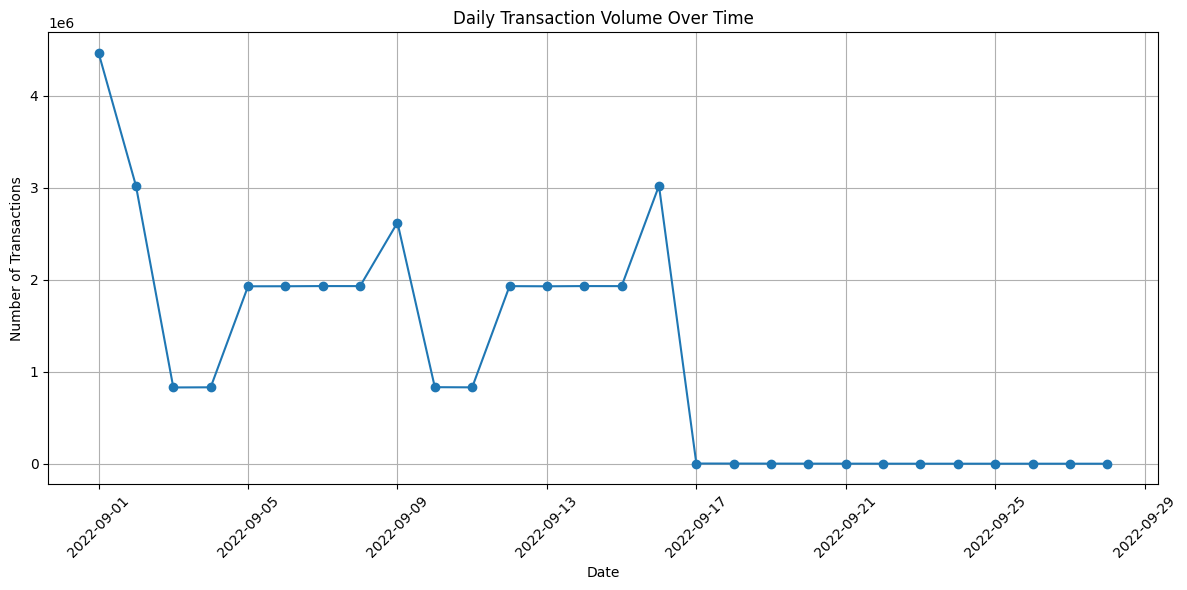

In [156]:
plt.figure(figsize=(12, 6))
plt.plot(
    daily_volume["transaction_date"],
    daily_volume["daily_transaction_count"],
    marker='o',
    linestyle='-'
)

plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.title("Daily Transaction Volume Over Time")

plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

Daily transaction volume varies substantially across the dataset period. The highest observed volume occurs at the beginning of the dataset, with approximately 4.47 million transactions on 1 September, while transaction counts decline considerably toward the end of the period. This demonstrates that transaction activity is not evenly distributed across dates.

## Hourly transaction volume

### This analysis groups transactions by hour of day to identify whether transaction activity is evenly distributed throughout the day or concentrated during particular hours.

In [157]:
hourly_volume = (
    df.with_columns(
        pl.col("timestamp").dt.hour().alias("transaction_hour")
    )
    .group_by("transaction_hour")
    .agg(
        pl.len().alias("hourly_transaction_count")
    )
    .sort("transaction_hour")
    .collect(engine="streaming")

)

hourly_volume

transaction_hour,hourly_transaction_count
i8,u32
0,3372880
1,1238053
2,1237519
3,1240536
4,1241507
…,…
19,1238812
20,1241063
21,1239448


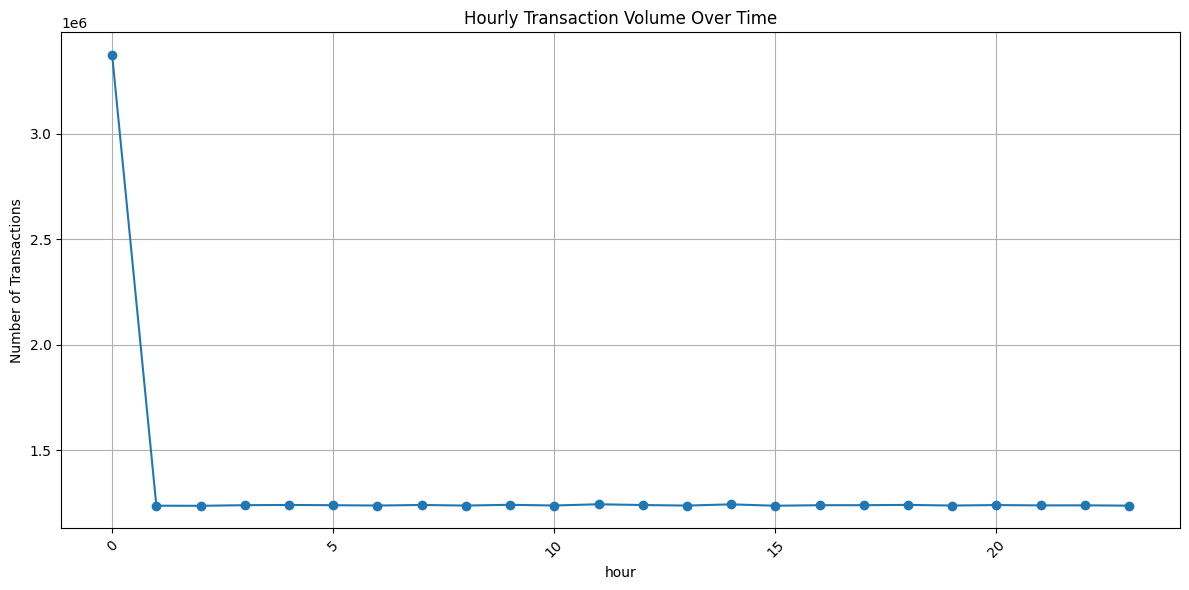

In [158]:
plt.figure(figsize=(12, 6))
plt.plot(
    hourly_volume["transaction_hour"],
    hourly_volume["hourly_transaction_count"],
    marker='o',
    linestyle='-'
)

plt.xlabel("hour")
plt.ylabel("Number of Transactions")
plt.title("Hourly Transaction Volume Over Time")

plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

Transaction activity is relatively similar across most hours, with approximately 1.24 million transactions per hour. However, hour 00:00 contains approximately 3.37 million transactions, substantially more than the other hours. This indicates a strong concentration of transactions around midnight that may be relevant to later temporal feature analysis.

## EDA Summary

The exploratory analysis shows that the HI-Medium dataset is a large and highly imbalanced AML dataset with approximately 31.9 million transactions and only 0.11% laundering-labelled transactions. No missing, negative, or zero transaction amounts were identified. Transaction amounts and sender activity are highly right-skewed, indicating the need for appropriate transformations and robust preprocessing.

The dataset contains diverse payment formats, currencies, banks, and account identities. Most transactions are cross-bank, while cross-currency transactions are relatively uncommon. Account-level analysis shows that transaction-history length varies substantially between senders. Approximately 19.60% of sender accounts contain at least 20 transactions, which is an important consideration when constructing fixed-length sequences for the GRU/LSTM models.

Temporal analysis also shows substantial variation in both transaction intervals and transaction volume. These findings will guide the next stage of the project, including data preprocessing, feature engineering, chronological splitting, and sequence construction.